# Vektordatenbanken – Explorative Analyse des OpenAlex-Korpus

Dieses Notebook dient der Vorbereitung eines Surveys zum aktuellen Forschungsstand rund um **Vektordatenbanken**.
Datengrundlage sind 3999 aus OpenAlex importierte wissenschaftliche Arbeiten in einer lokalen Postgres-Datenbank.

Ziel ist es, statt alle Arbeiten einzeln zu lesen, den Korpus zunächst quantitativ zu erschließen:

1. Überblick über den Gesamtkorpus (Menge, Zeitverlauf, Typen, Open Access)
2. Fachliche Kategorisierung nach Domain → Field → Subfield → Topic
3. Vertiefung des Bereichs **Computer Science**
4. Zitations-, Keyword-, Kooperations- und Förder-Analysen
5. Cross-Domain-Analyse zur Identifikation von Anwendungsbereichen
6. Ableitung möglicher **Forschungslücken**

Die Ergebnisse dieses Notebooks sollen als Landkarte dienen, um gezielt Teilbereiche für die vertiefte Literaturarbeit auszuwählen.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from database.scripts.config import load_config
from database.scripts.connect import connect

import warnings

warnings.filterwarnings("ignore")

# DB-Konfiguration laden und Verbindung aufbauen
config = load_config("database/scripts/database.ini")
conn = connect(config)

# Schema setzen, damit Tabellen ohne "openalex."-Prefix angesprochen werden koennen
with conn.cursor() as cur:
    cur.execute("SET search_path TO openalex, public;")
conn.commit()

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

Connected to the PostgreSQL server.


## 1. Überblick über den Gesamtkorpus

Zunächst ein paar Kennzahlen zum gesamten Datensatz: Anzahl der Arbeiten, abgedeckter Zeitraum,
durchschnittliche Zitationshäufigkeit sowie der Anteil an Open-Access- und zurückgezogenen (retracted) Arbeiten.
Das gibt ein erstes Gefühl für Qualität und Umfang der Datenbasis.

In [61]:
query_overview = """
SELECT COUNT(*) AS anzahl_arbeiten,
       MIN(publication_year) AS erstes_jahr,
       MAX(publication_year) AS letztes_jahr,
       ROUND(AVG(cited_by_count), 2) AS avg_zitationen,
       SUM(CASE WHEN is_open_access THEN 1 ELSE 0 END) AS anzahl_open_access,
       SUM(CASE WHEN is_retracted THEN 1 ELSE 0 END) AS anzahl_retracted
FROM work;
"""

df_overview = pd.read_sql(query_overview, conn)
df_overview

,anzahl_arbeiten,erstes_jahr,letztes_jahr,avg_zitationen,anzahl_open_access,anzahl_retracted
0,3860,1970,2026,9.75,3568,3


### 1.1 Publikationen pro Jahr

Die zeitliche Entwicklung der Publikationszahlen zeigt, wie sich das Forschungsinteresse an
Vektordatenbanken über die Jahre entwickelt hat (z. B. sprunghafter Anstieg im Zuge von
Retrieval-Augmented-Generation / LLM-Anwendungen ab ca. 2022/2023).

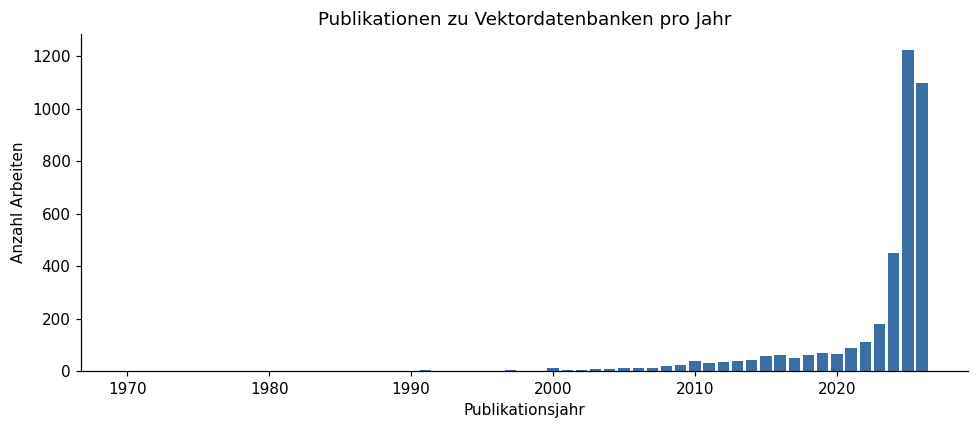

,publication_year,anzahl_arbeiten
0,1970,1
1,1989,1
2,1990,2
3,1991,4
4,1992,1
5,1993,2
6,1994,2
7,1995,1
8,1996,2
9,1997,3


In [62]:
query_per_year = """
SELECT publication_year, COUNT(*) AS anzahl_arbeiten
FROM work
WHERE publication_year IS NOT NULL
GROUP BY publication_year
ORDER BY publication_year;
"""

df_per_year = pd.read_sql(query_per_year, conn)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(df_per_year["publication_year"], df_per_year["anzahl_arbeiten"], color="#3b6ea5")
ax.set_xlabel("Publikationsjahr")
ax.set_ylabel("Anzahl Arbeiten")
ax.set_title("Publikationen zu Vektordatenbanken pro Jahr")
plt.tight_layout()
plt.show()

df_per_year

### 1.2 Publikationstypen, Sprache und Open Access

Verteilung nach `work_type` (Artikel, Preprint, Konferenzbeitrag, ...), Sprache sowie Open-Access-Anteil.
Das hilft z. B. einzuschätzen, wie viel Preprint-Material (potenziell noch nicht begutachtet) im Korpus steckt.

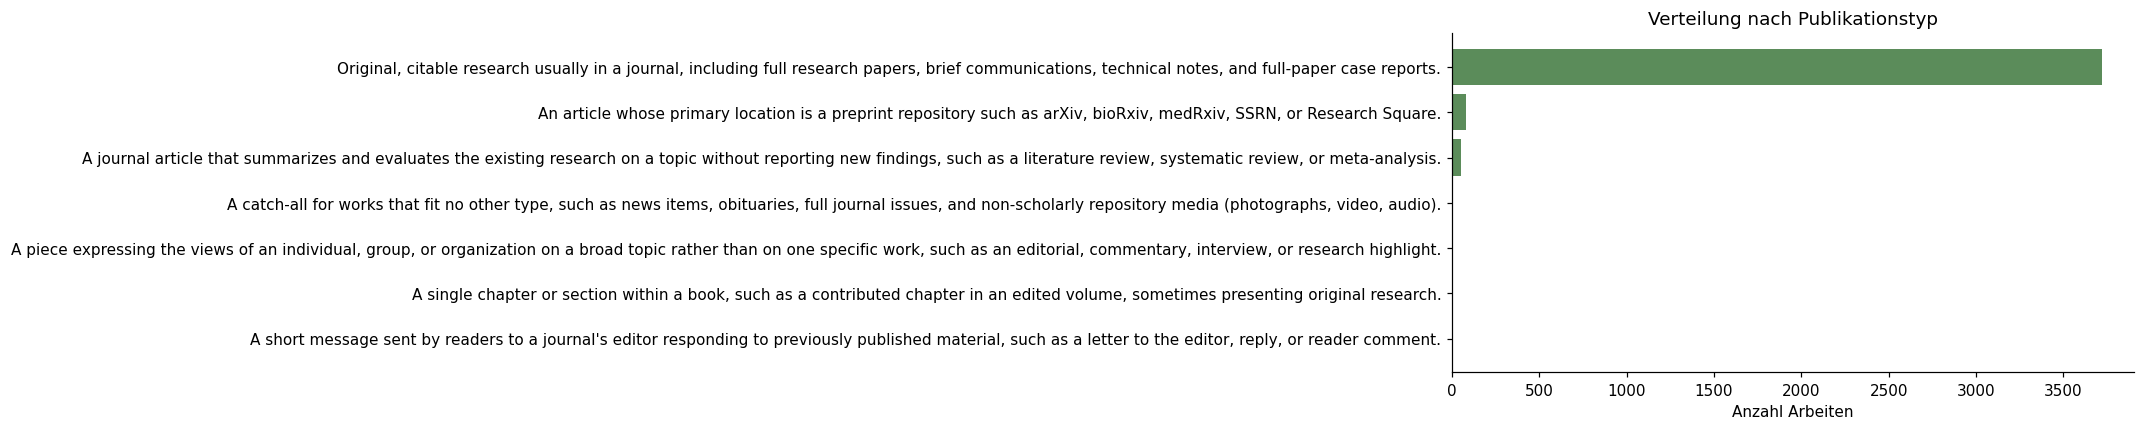

,typ,anzahl
0,"Original, citable research usually in a journal, including full research papers, brief communications, technical not...",3719
1,"An article whose primary location is a preprint repository such as arXiv, bioRxiv, medRxiv, SSRN, or Research Square.",82
2,"A journal article that summarizes and evaluates the existing research on a topic without reporting new findings, suc...",49
3,"A catch-all for works that fit no other type, such as news items, obituaries, full journal issues, and non-scholarly...",5
4,"A piece expressing the views of an individual, group, or organization on a broad topic rather than on one specific w...",3
5,"A single chapter or section within a book, such as a contributed chapter in an edited volume, sometimes presenting o...",1
6,"A short message sent by readers to a journal's editor responding to previously published material, such as a letter ...",1


In [63]:
query_worktype = """
SELECT COALESCE(wt.display_description, 'unbekannt') AS typ, COUNT(*) AS anzahl
FROM work w
LEFT JOIN work_type wt ON w.type_id = wt.id
GROUP BY typ
ORDER BY anzahl DESC;
"""

df_worktype = pd.read_sql(query_worktype, conn)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(df_worktype["typ"], df_worktype["anzahl"], color="#5b8c5a")
ax.invert_yaxis()
ax.set_xlabel("Anzahl Arbeiten")
ax.set_title("Verteilung nach Publikationstyp")
plt.tight_layout()
plt.show()

df_worktype

In [64]:
query_language = """
SELECT COALESCE(l.display_name, 'unbekannt') AS sprache, COUNT(*) AS anzahl
FROM work w
LEFT JOIN languages l ON w.language_code_alpha_2_3 = l.code_alpha_2_3
GROUP BY sprache
ORDER BY anzahl DESC
LIMIT 10;
"""

df_language = pd.read_sql(query_language, conn)
df_language

,sprache,anzahl
0,English,2893
1,unbekannt,860
2,Ukrainian,16
3,Russian,13
4,Indonesian,11
5,Portuguese,10
6,Spanish,9
7,Turkish,7
8,Croatian,6
9,German,5


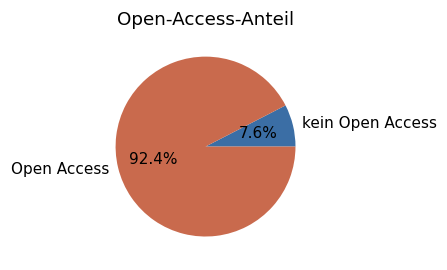

,is_open_access,anzahl,anteil_prozent
0,False,292,7.6
1,True,3568,92.4


In [65]:
query_oa = """
SELECT is_open_access, COUNT(*) AS anzahl,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS anteil_prozent
FROM work
GROUP BY is_open_access;
"""

df_oa = pd.read_sql(query_oa, conn)

fig, ax = plt.subplots(figsize=(4, 4))
labels = df_oa["is_open_access"].map({True: "Open Access", False: "kein Open Access"}).fillna("unbekannt")
ax.pie(df_oa["anzahl"], labels=labels, autopct="%1.1f%%", colors=["#3b6ea5", "#c96a4d"])
ax.set_title("Open-Access-Anteil")
plt.tight_layout()
plt.show()

df_oa

## 2. Fachliche Kategorisierung: Domain → Field → Subfield → Topic

OpenAlex ordnet jedem Werk über `work_topic` ein oder mehrere Topics mit einem Relevanz-`score` zu.
Jedes Topic gehört eindeutig zu einem Subfield, jedes Subfield zu einem Field und jedes Field zu einer
von vier übergeordneten Domains (z. B. "Physical Sciences", "Life Sciences", ...).

Für eine **eindeutige Klassifikation pro Arbeit** wird hier jeweils das Topic mit dem höchsten Score
als *primäres Topic* gewählt (`DISTINCT ON (work_id) ... ORDER BY score DESC`). Das liefert eine
saubere 1:1-Zuordnung Arbeit → Domain/Field/Subfield/Topic, auf der die folgenden Auswertungen basieren.
Für die Cross-Domain-Analyse in Abschnitt 5 werden zusätzlich die *sekundären* Topics herangezogen.

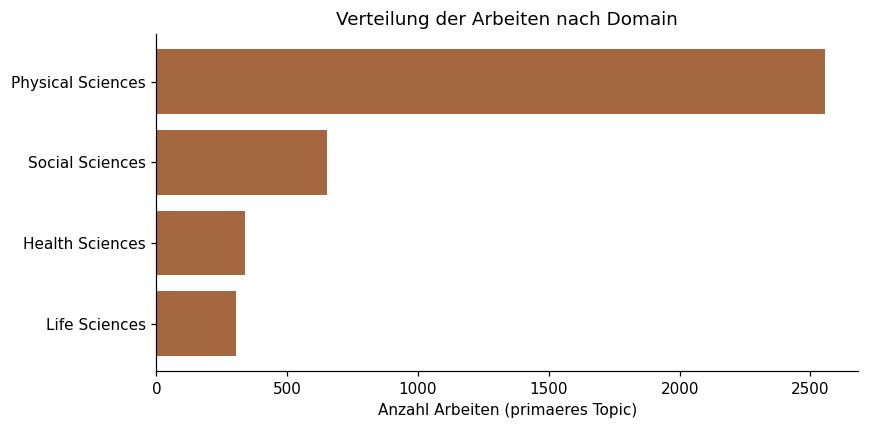

,domain,anzahl_arbeiten
0,Physical Sciences,2554
1,Social Sciences,653
2,Health Sciences,339
3,Life Sciences,303


In [66]:
query_domain = """
WITH primary_topic AS (
    SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id, wt.score
    FROM work_topic wt
    ORDER BY wt.work_id, wt.score DESC
)
SELECT d.display_name AS domain, COUNT(*) AS anzahl_arbeiten
FROM primary_topic pt
JOIN topic t ON pt.topic_id = t.id
JOIN subfield sf ON t.subfield_id = sf.id
JOIN field f ON sf.field_id = f.id
JOIN domain d ON f.domain_id = d.id
GROUP BY d.display_name
ORDER BY anzahl_arbeiten DESC;
"""

df_domain = pd.read_sql(query_domain, conn)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(df_domain["domain"], df_domain["anzahl_arbeiten"], color="#a5673f")
ax.invert_yaxis()
ax.set_xlabel("Anzahl Arbeiten (primaeres Topic)")
ax.set_title("Verteilung der Arbeiten nach Domain")
plt.tight_layout()
plt.show()

df_domain

### 2.1 Verteilung nach Field (Top 20)

"Computer Science" ist in der OpenAlex-Taxonomie ein *Field* (nicht die oberste Ebene "Domain").
Hier zeigt sich, wie dominant CS im Vektordatenbank-Korpus ist und welche anderen Fields relevant sind.

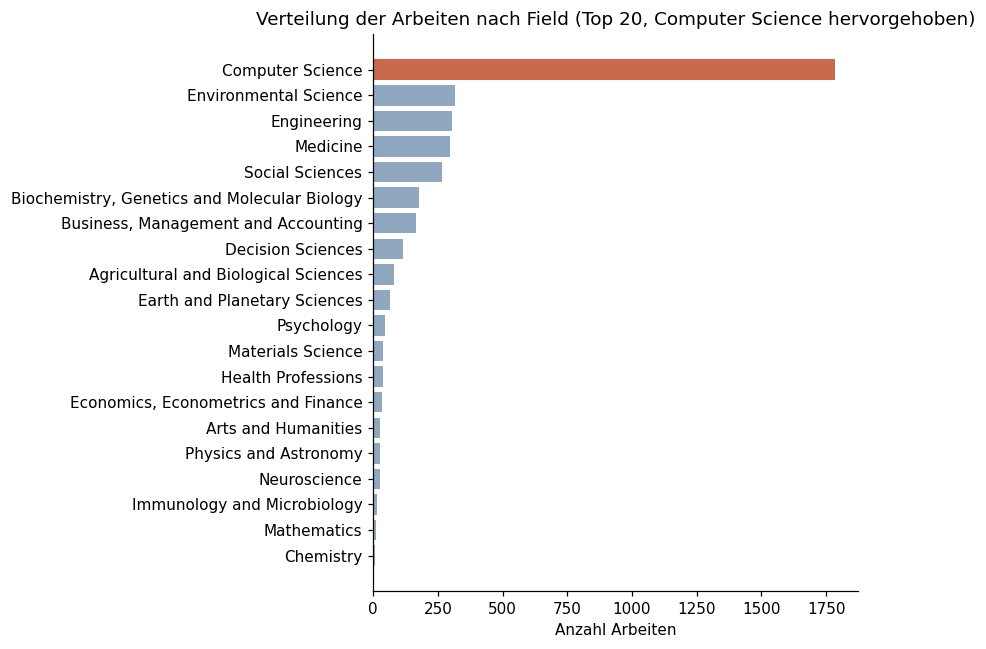

,field,anzahl_arbeiten
0,Computer Science,1784
1,Environmental Science,317
2,Engineering,305
3,Medicine,296
4,Social Sciences,265
5,"Biochemistry, Genetics and Molecular Biology",177
6,"Business, Management and Accounting",164
7,Decision Sciences,117
8,Agricultural and Biological Sciences,81
9,Earth and Planetary Sciences,65


In [67]:
query_field = """
WITH primary_topic AS (
    SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id, wt.score
    FROM work_topic wt
    ORDER BY wt.work_id, wt.score DESC
)
SELECT f.display_name AS field, COUNT(*) AS anzahl_arbeiten
FROM primary_topic pt
JOIN topic t ON pt.topic_id = t.id
JOIN subfield sf ON t.subfield_id = sf.id
JOIN field f ON sf.field_id = f.id
GROUP BY f.display_name
ORDER BY anzahl_arbeiten DESC
LIMIT 20;
"""

df_field = pd.read_sql(query_field, conn)

colors = ["#c96a4d" if f == "Computer Science" else "#8fa8bf" for f in df_field["field"]]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(df_field["field"], df_field["anzahl_arbeiten"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Anzahl Arbeiten")
ax.set_title("Verteilung der Arbeiten nach Field (Top 20, Computer Science hervorgehoben)")
plt.tight_layout()
plt.show()

df_field

## 3. Fokus: Computer Science

Ab hier wird der Korpus auf Arbeiten eingeschränkt, deren *primäres* Topic im Field "Computer Science" liegt.
Zunächst die Verteilung nach Subfield, danach die konkreten Topics.

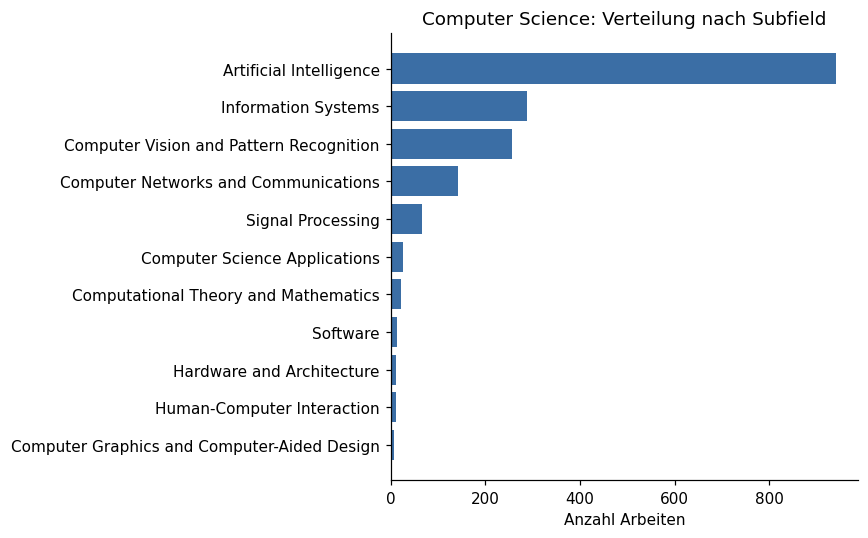

,subfield,anzahl_arbeiten
0,Artificial Intelligence,940
1,Information Systems,288
2,Computer Vision and Pattern Recognition,256
3,Computer Networks and Communications,143
4,Signal Processing,66
5,Computer Science Applications,27
6,Computational Theory and Mathematics,21
7,Software,13
8,Hardware and Architecture,12
9,Human-Computer Interaction,11


In [68]:
query_cs_subfield = """
WITH primary_topic AS (
    SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id, wt.score
    FROM work_topic wt
    ORDER BY wt.work_id, wt.score DESC
)
SELECT sf.display_name AS subfield, COUNT(*) AS anzahl_arbeiten
FROM primary_topic pt
JOIN topic t ON pt.topic_id = t.id
JOIN subfield sf ON t.subfield_id = sf.id
JOIN field f ON sf.field_id = f.id
WHERE f.display_name = 'Computer Science'
GROUP BY sf.display_name
ORDER BY anzahl_arbeiten DESC;
"""

df_cs_subfield = pd.read_sql(query_cs_subfield, conn)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_cs_subfield["subfield"], df_cs_subfield["anzahl_arbeiten"], color="#3b6ea5")
ax.invert_yaxis()
ax.set_xlabel("Anzahl Arbeiten")
ax.set_title("Computer Science: Verteilung nach Subfield")
plt.tight_layout()
plt.show()

df_cs_subfield

### 3.1 Top-Topics innerhalb Computer Science

Die feinste Granularität der OpenAlex-Taxonomie ist das Topic. Die folgenden Top-20-Topics
zeigen die konkreten thematischen Schwerpunkte innerhalb der CS-Arbeiten zu Vektordatenbanken
(z. B. Vector Search, Approximate Nearest Neighbor, Embeddings, Retrieval-Augmented Generation, ...).

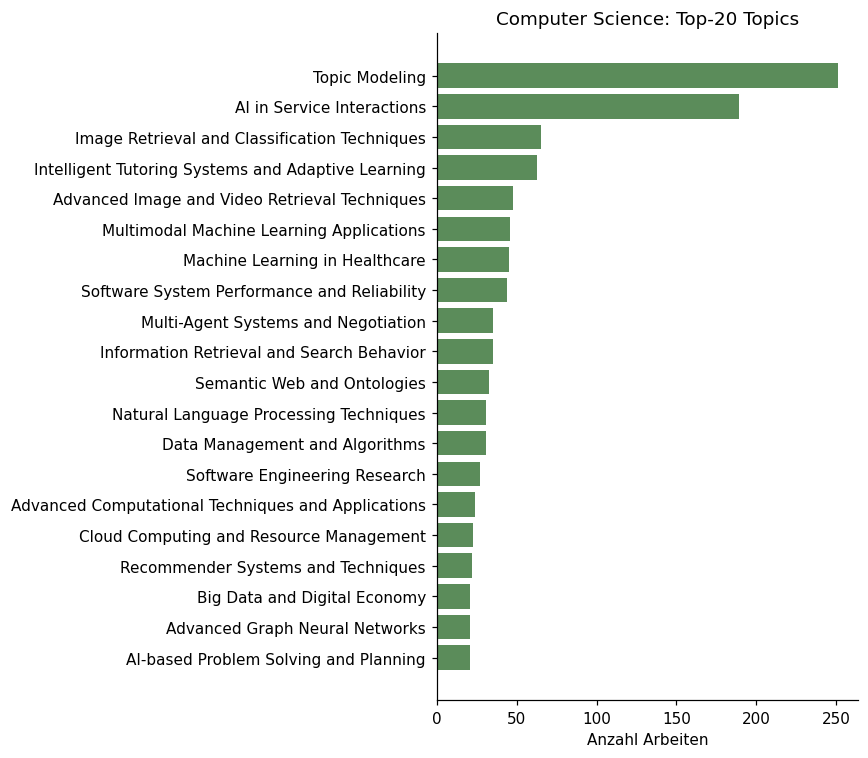

,topic,anzahl_arbeiten
0,Topic Modeling,251
1,AI in Service Interactions,189
2,Image Retrieval and Classification Techniques,65
3,Intelligent Tutoring Systems and Adaptive Learning,63
4,Advanced Image and Video Retrieval Techniques,48
5,Multimodal Machine Learning Applications,46
6,Machine Learning in Healthcare,45
7,Software System Performance and Reliability,44
8,Multi-Agent Systems and Negotiation,35
9,Information Retrieval and Search Behavior,35


In [69]:
query_cs_topic = """
WITH primary_topic AS (
    SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id, wt.score
    FROM work_topic wt
    ORDER BY wt.work_id, wt.score DESC
)
SELECT t.display_name AS topic, COUNT(*) AS anzahl_arbeiten
FROM primary_topic pt
JOIN topic t ON pt.topic_id = t.id
JOIN subfield sf ON t.subfield_id = sf.id
JOIN field f ON sf.field_id = f.id
WHERE f.display_name = 'Computer Science'
GROUP BY t.display_name
ORDER BY anzahl_arbeiten DESC
LIMIT 20;
"""

df_cs_topic = pd.read_sql(query_cs_topic, conn)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(df_cs_topic["topic"], df_cs_topic["anzahl_arbeiten"], color="#5b8c5a")
ax.invert_yaxis()
ax.set_xlabel("Anzahl Arbeiten")
ax.set_title("Computer Science: Top-20 Topics")
plt.tight_layout()
plt.show()

df_cs_topic

### 3.2 Zeitliche Entwicklung der Top-Topics in CS

Um zu erkennen, welche Teilgebiete aktuell an Bedeutung gewinnen bzw. verlieren, wird die Anzahl
Publikationen je Top-10-Topic und Jahr als Heatmap dargestellt. Das ist besonders hilfreich, um
"heiße" (stark wachsende) von etablierten, eher stabilen Themen zu unterscheiden.

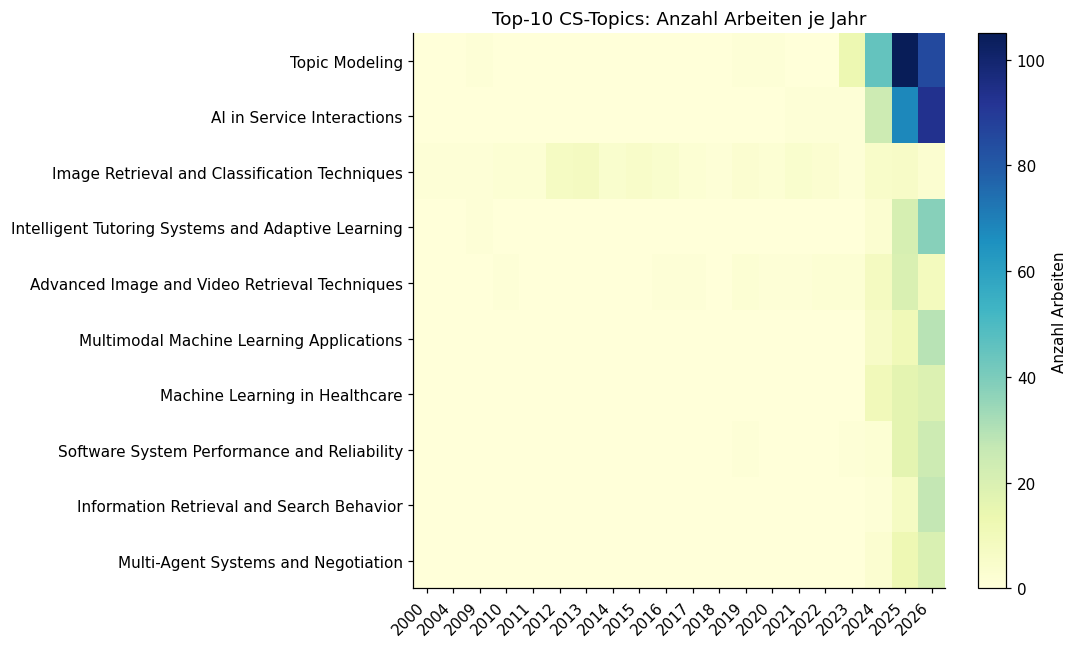

publication_year,2000,2004,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
topic,,,,,,,,,,,,,,,,,,,,
Topic Modeling,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,13.0,45.0,105.0,85.0
AI in Service Interactions,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,24.0,68.0,93.0
Image Retrieval and Classification Techniques,1.0,1.0,1.0,2.0,2.0,7.0,8.0,4.0,5.0,4.0,2.0,1.0,3.0,2.0,4.0,3.0,1.0,5.0,6.0,3.0
Intelligent Tutoring Systems and Adaptive Learning,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,21.0,38.0
Advanced Image and Video Retrieval Techniques,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,2.0,1.0,1.0,2.0,2.0,8.0,20.0,9.0
Multimodal Machine Learning Applications,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,11.0,29.0
Machine Learning in Healthcare,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,16.0,19.0
Software System Performance and Reliability,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,16.0,24.0
Information Retrieval and Search Behavior,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,7.0,27.0


In [70]:
query_cs_topic_year = """
WITH primary_topic AS (
    SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id, wt.score
    FROM work_topic wt
    ORDER BY wt.work_id, wt.score DESC
),
cs_topic_work AS (
    SELECT pt.work_id, t.display_name AS topic
    FROM primary_topic pt
    JOIN topic t ON pt.topic_id = t.id
    JOIN subfield sf ON t.subfield_id = sf.id
    JOIN field f ON sf.field_id = f.id
    WHERE f.display_name = 'Computer Science'
),
top_topics AS (
    SELECT topic FROM cs_topic_work GROUP BY topic ORDER BY COUNT(*) DESC LIMIT 10
)
SELECT ctw.topic, w.publication_year, COUNT(*) AS anzahl
FROM cs_topic_work ctw
JOIN work w ON ctw.work_id = w.id
WHERE ctw.topic IN (SELECT topic FROM top_topics)
  AND w.publication_year IS NOT NULL
GROUP BY ctw.topic, w.publication_year
ORDER BY w.publication_year;
"""

df_topic_year = pd.read_sql(query_cs_topic_year, conn)

pivot = df_topic_year.pivot_table(index="topic", columns="publication_year",
                                   values="anzahl", fill_value=0)
# Zeilen nach Gesamtsumme sortieren, groesste oben
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title("Top-10 CS-Topics: Anzahl Arbeiten je Jahr")
fig.colorbar(im, ax=ax, label="Anzahl Arbeiten")
plt.tight_layout()
plt.show()

pivot

## 4. Zitations- und Einflussanalyse

Die meistzitierten Arbeiten sind gute Kandidaten für die "Kernliteratur" des Surveys.
Zusätzlich zeigt die durchschnittliche Zitationshäufigkeit je Topic, welche Teilgebiete
bereits stark rezipiert werden.

In [71]:
query_top_cited = """
SELECT title, publication_year, cited_by_count, doi
FROM work
ORDER BY cited_by_count DESC NULLS LAST
LIMIT 15;
"""

df_top_cited = pd.read_sql(query_top_cited, conn)
df_top_cited

,title,publication_year,cited_by_count,doi
0,Bilbao Crystallographic Server: I. Databases and crystallographic computing programs,2005,1171,https://doi.org/10.1524/zkri.2006.221.1.15
1,Development of NO2 and NOx land use regression models for estimating air pollution exposure in 36 study areas in Eur...,2013,1007,https://doi.org/10.1016/j.atmosenv.2013.02.037
2,A survey on large language model based autonomous agents,2024,910,https://doi.org/10.1007/s11704-024-40231-1
3,A global map of dominant malaria vectors,2012,759,https://doi.org/10.1186/1756-3305-5-69
4,Autonomous chemical research with large language models,2023,698,https://doi.org/10.1038/s41586-023-06792-0
5,Quality Assessment of the French OpenStreetMap Dataset,2010,666,https://doi.org/10.1111/j.1467-9671.2010.01203.x
6,"The dominant Anopheles vectors of human malaria in the Asia-Pacific region: occurrence data, distribution maps and b...",2011,570,https://doi.org/10.1186/1756-3305-4-89
7,Pharmacovigilance from social media: mining adverse drug reaction mentions using sequence labeling with word embeddi...,2015,551,https://doi.org/10.1093/jamia/ocu041
8,Augmenting large language models with chemistry tools,2024,487,https://doi.org/10.1038/s42256-024-00832-8
9,"Balancing Privacy and Progress: A Review of Privacy Challenges, Systemic Oversight, and Patient Perceptions in AI-Dr...",2024,428,https://doi.org/10.3390/app14020675


In [72]:
query_avg_cited_topic = """
WITH primary_topic AS (
    SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id, wt.score
    FROM work_topic wt
    ORDER BY wt.work_id, wt.score DESC
),
cs_topic_work AS (
    SELECT pt.work_id, t.display_name AS topic
    FROM primary_topic pt
    JOIN topic t ON pt.topic_id = t.id
    JOIN subfield sf ON t.subfield_id = sf.id
    JOIN field f ON sf.field_id = f.id
    WHERE f.display_name = 'Computer Science'
)
SELECT ctw.topic,
       COUNT(*) AS anzahl_arbeiten,
       ROUND(AVG(w.cited_by_count), 1) AS avg_zitationen
FROM cs_topic_work ctw
JOIN work w ON ctw.work_id = w.id
GROUP BY ctw.topic
HAVING COUNT(*) >= 5
ORDER BY avg_zitationen DESC
LIMIT 20;
"""

df_avg_cited_topic = pd.read_sql(query_avg_cited_topic, conn)
df_avg_cited_topic

,topic,anzahl_arbeiten,avg_zitationen
0,Reinforcement Learning in Robotics,5,182.0
1,Computational Drug Discovery Methods,10,19.0
2,Machine Learning and Data Classification,5,18.2
3,Caching and Content Delivery,5,14.6
4,Image Retrieval and Classification Techniques,65,9.6
5,Explainable Artificial Intelligence (XAI),11,9.4
6,Imbalanced Data Classification Techniques,6,9.2
7,Biometric Identification and Security,10,9.2
8,Advanced Data Storage Technologies,11,8.6
9,Web Data Mining and Analysis,5,8.6


### 4.1 Häufigste Keywords

Ergänzend zur Topic-Klassifikation liefert OpenAlex freitextnähere Keywords je Arbeit
(mit Relevanzscore). Das hilft, konkrete Begriffe (z. B. "HNSW", "approximate nearest neighbor",
"embedding") für spätere gezielte Literaturrecherchen zu identifizieren.

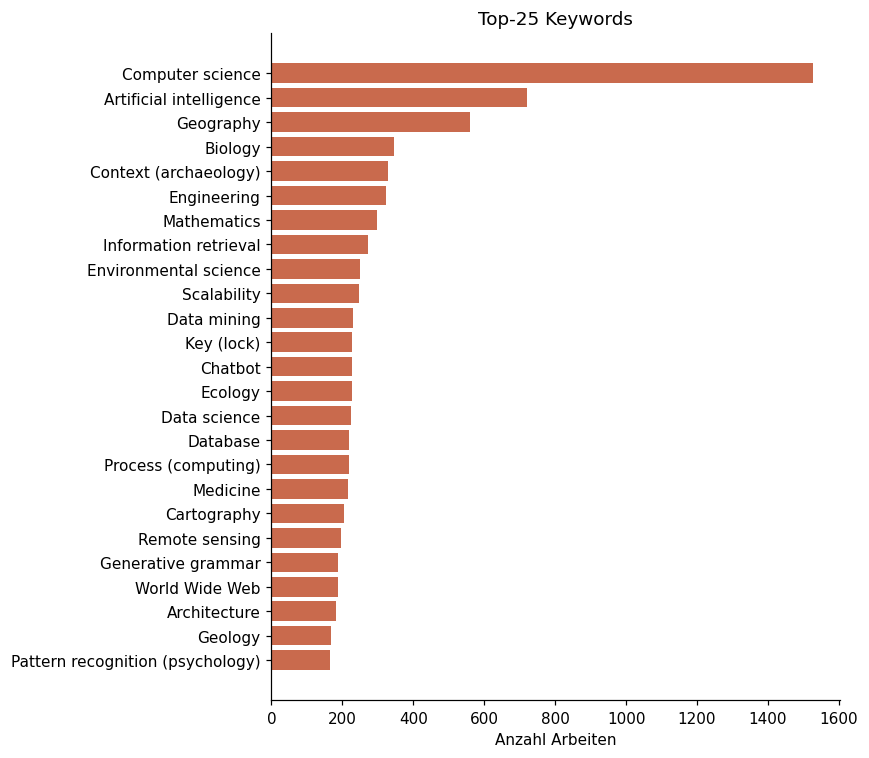

,keyword,anzahl,avg_score
0,Computer science,1527,0.546
1,Artificial intelligence,720,0.386
2,Geography,561,0.359
3,Biology,345,0.404
4,Context (archaeology),330,0.518
5,Engineering,323,0.195
6,Mathematics,299,0.214
7,Information retrieval,273,0.434
8,Environmental science,250,0.422
9,Scalability,248,0.547


In [73]:
query_keywords = """
SELECT k.display_name AS keyword, COUNT(*) AS anzahl, ROUND(AVG(wk.score)::numeric, 3) AS avg_score
FROM work_keyword wk
JOIN keyword k ON wk.keyword_id = k.id
GROUP BY k.display_name
ORDER BY anzahl DESC
LIMIT 25;
"""

df_keywords = pd.read_sql(query_keywords, conn)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(df_keywords["keyword"], df_keywords["anzahl"], color="#c96a4d")
ax.invert_yaxis()
ax.set_xlabel("Anzahl Arbeiten")
ax.set_title("Top-25 Keywords")
plt.tight_layout()
plt.show()

df_keywords

## 5. Geografische Verteilung, Institutionen und Kooperation

Diese Auswertungen zeigen, welche Länder und Institutionen die Forschung zu Vektordatenbanken
treiben und wie stark international kooperiert wird.

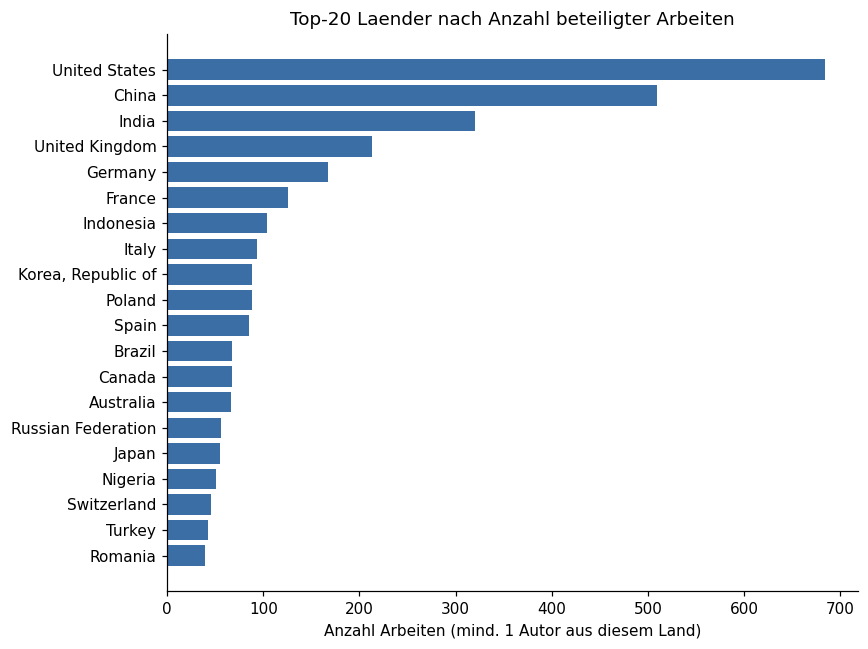

,land,anzahl_arbeiten
0,United States,684
1,China,509
2,India,320
3,United Kingdom,213
4,Germany,167
5,France,126
6,Indonesia,104
7,Italy,93
8,"Korea, Republic of",88
9,Poland,88


In [74]:
query_countries = """
SELECT c.display_name AS land, COUNT(DISTINCT wa.work_id) AS anzahl_arbeiten
FROM work_author wa
JOIN author_country ac ON wa.author_id = ac.author_id
JOIN country c ON ac.country_code_alpha_2 = c.code_alpha_2
GROUP BY c.display_name
ORDER BY anzahl_arbeiten DESC
LIMIT 20;
"""

df_countries = pd.read_sql(query_countries, conn)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(df_countries["land"], df_countries["anzahl_arbeiten"], color="#3b6ea5")
ax.invert_yaxis()
ax.set_xlabel("Anzahl Arbeiten (mind. 1 Autor aus diesem Land)")
ax.set_title("Top-20 Laender nach Anzahl beteiligter Arbeiten")
plt.tight_layout()
plt.show()

df_countries

In [75]:
query_institutions = """
SELECT i.display_name AS institution, COUNT(DISTINCT wai.work_id) AS anzahl_arbeiten
FROM work_author_institution wai
JOIN institution i ON wai.institution_id = i.id
GROUP BY i.display_name
ORDER BY anzahl_arbeiten DESC
LIMIT 15;
"""

df_institutions = pd.read_sql(query_institutions, conn)
df_institutions

,institution,anzahl_arbeiten
0,Centre National de la Recherche Scientifique,41
1,Chinese Academy of Sciences,39
2,Film Independent,31
3,Tsinghua University,30
4,University of Chinese Academy of Sciences,27
5,University of Oxford,16
6,Institut national de l’information géographique et forestière,14
7,Babeș-Bolyai University,14
8,Wuhan University,13
9,UNSW Sydney,13


In [76]:
query_inst_type = """
SELECT COALESCE(it.display_name, 'unbekannt') AS institutionstyp,
       COUNT(DISTINCT i.id) AS anzahl_institutionen
FROM institution i
LEFT JOIN institution_type it ON i.institution_type_id = it.id
GROUP BY institutionstyp
ORDER BY anzahl_institutionen DESC;
"""

df_inst_type = pd.read_sql(query_inst_type, conn)
df_inst_type

,institutionstyp,anzahl_institutionen
0,education,2125
1,facility,521
2,company,311
3,healthcare,278
4,government,191
5,nonprofit,146
6,other,68
7,funder,47
8,archive,20
9,unbekannt,8


### 5.1 Internationale Kooperation im Zeitverlauf

Anteil der Arbeiten pro Jahr, deren Autor:innen aus mehr als einem Land stammen.
Ein steigender Anteil deutet auf eine zunehmende Internationalisierung des Forschungsfelds hin.

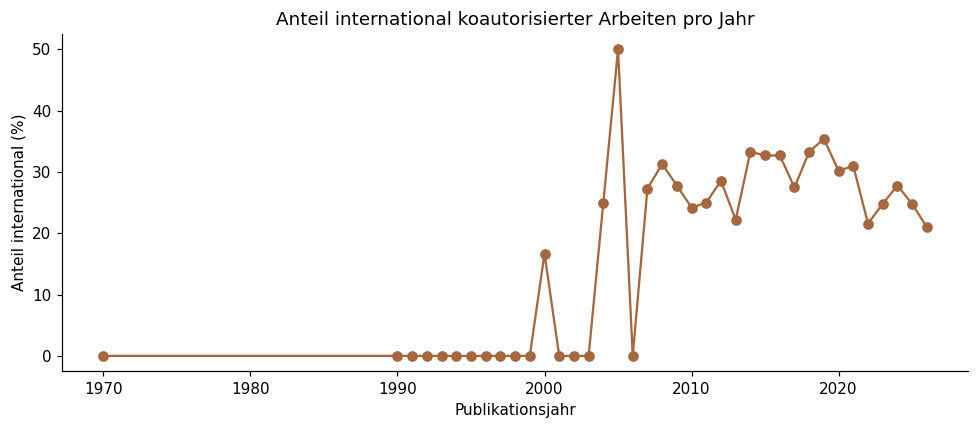

,publication_year,anzahl_arbeiten,anzahl_international,anteil_international_prozent
0,1970,1,0,0.0
1,1990,1,0,0.0
2,1991,3,0,0.0
3,1992,1,0,0.0
4,1993,1,0,0.0
5,1994,2,0,0.0
6,1995,1,0,0.0
7,1996,1,0,0.0
8,1997,2,0,0.0
9,1998,1,0,0.0


In [77]:
query_international = """
WITH work_countries AS (
    SELECT wa.work_id, COUNT(DISTINCT ac.country_code_alpha_2) AS anzahl_laender
    FROM work_author wa
    JOIN author_country ac ON wa.author_id = ac.author_id
    GROUP BY wa.work_id
)
SELECT w.publication_year,
       COUNT(*) AS anzahl_arbeiten,
       SUM(CASE WHEN wc.anzahl_laender > 1 THEN 1 ELSE 0 END) AS anzahl_international,
       ROUND(100.0 * SUM(CASE WHEN wc.anzahl_laender > 1 THEN 1 ELSE 0 END) / COUNT(*), 1) AS anteil_international_prozent
FROM work w
JOIN work_countries wc ON w.id = wc.work_id
WHERE w.publication_year IS NOT NULL
GROUP BY w.publication_year
ORDER BY w.publication_year;
"""

df_international = pd.read_sql(query_international, conn)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_international["publication_year"], df_international["anteil_international_prozent"],
        marker="o", color="#a5673f")
ax.set_xlabel("Publikationsjahr")
ax.set_ylabel("Anteil international (%)")
ax.set_title("Anteil international koautorisierter Arbeiten pro Jahr")
plt.tight_layout()
plt.show()

df_international

### 5.2 Förderung und Publikationsorgane

Top-Förderorganisationen sowie die wichtigsten Journals/Konferenzen und Quelltypen
(Journal, Conference, Repository, ...) geben Hinweise auf die Publikationskultur des Feldes.

In [78]:
query_funder = """
SELECT f.display_name AS funder, COUNT(DISTINCT wf.work_id) AS anzahl_arbeiten
FROM work_funder wf
JOIN funder f ON wf.funder_id = f.id
GROUP BY f.display_name
ORDER BY anzahl_arbeiten DESC
LIMIT 15;
"""

df_funder = pd.read_sql(query_funder, conn)
df_funder

,funder,anzahl_arbeiten
0,National Natural Science Foundation of China,163
1,European Commission,93
2,National Science Foundation,78
3,National Institutes of Health,62
4,National Key Research and Development Program of China,41
5,U.S. Department of Energy,28
6,Deutsche Forschungsgemeinschaft,27
7,Agence Nationale de la Recherche,22
8,"Ministry of Science and ICT, South Korea",19
9,HORIZON EUROPE Framework Programme,16


In [79]:
query_sources = """
SELECT s.display_name AS quelle, COALESCE(st.display_name, 'unbekannt') AS quelltyp,
       COUNT(DISTINCT wl.work_id) AS anzahl_arbeiten
FROM work_locations wl
JOIN locations l ON wl.locations_id = l.id
JOIN source s ON l.source_id = s.id
LEFT JOIN source_type st ON s.source_type_id = st.id
WHERE wl.is_primary = TRUE
GROUP BY s.display_name, quelltyp
ORDER BY anzahl_arbeiten DESC
LIMIT 15;
"""

df_sources = pd.read_sql(query_sources, conn)
df_sources

,quelle,quelltyp,anzahl_arbeiten
0,Zenodo (CERN European Organization for Nuclear Research),repository,112
1,International Journal for Research in Applied Science and Engineering Technology,journal,80
2,Applied Sciences,journal,71
3,Electronics,journal,64
4,INTERANTIONAL JOURNAL OF SCIENTIFIC RESEARCH IN ENGINEERING AND MANAGEMENT,journal,63
5,Scientific Reports,journal,60
6,arXiv (Cornell University),repository,42
7,Remote Sensing,journal,34
8,"The international archives of the photogrammetry, remote sensing and spatial information sciences/International ar...",journal,33
9,IEEE Access,journal,31


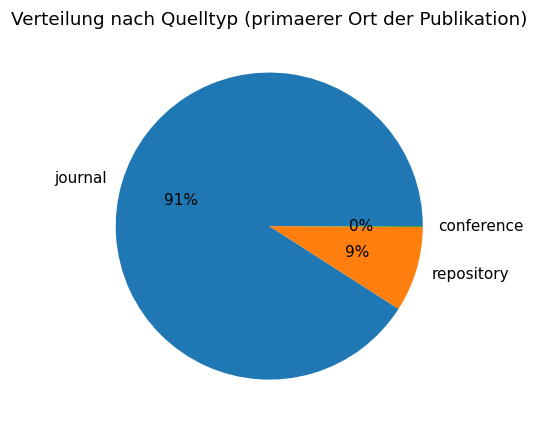

,quelltyp,anzahl_arbeiten
0,journal,3450
1,repository,340
2,conference,4


In [80]:
query_source_type = """
SELECT COALESCE(st.display_name, 'unbekannt') AS quelltyp,
       COUNT(DISTINCT wl.work_id) AS anzahl_arbeiten
FROM work_locations wl
JOIN locations l ON wl.locations_id = l.id
LEFT JOIN source s ON l.source_id = s.id
LEFT JOIN source_type st ON s.source_type_id = st.id
WHERE wl.is_primary = TRUE
GROUP BY quelltyp
ORDER BY anzahl_arbeiten DESC;
"""

df_source_type = pd.read_sql(query_source_type, conn)

fig, ax = plt.subplots(figsize=(6, 4))
ax.pie(df_source_type["anzahl_arbeiten"], labels=df_source_type["quelltyp"], autopct="%1.0f%%")
ax.set_title("Verteilung nach Quelltyp (primaerer Ort der Publikation)")
plt.tight_layout()
plt.show()

df_source_type

## 6. Cross-Domain-Analyse: In welchen Bereichen werden Vektordatenbanken eingesetzt?

Diese Analyse betrachtet Arbeiten, deren *primäres* Topic in Computer Science liegt, und schaut,
welche *sekundären* Topics (aus anderen Fields/Domains) diesen Arbeiten zusätzlich zugeordnet sind.
Das macht sichtbar, in welchen Anwendungsdomänen (z. B. Medizin, Biologie, Sozialwissenschaften)
Vektordatenbank-bezogene CS-Forschung eine Rolle spielt – genau die Information, die für den
"Einsatzbereiche"-Teil deines Surveys relevant ist.

In [81]:
query_cross_domain = """
WITH primary_topic AS (
    SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id
    FROM work_topic wt
    ORDER BY wt.work_id, wt.score DESC
),
cs_works AS (
    SELECT pt.work_id
    FROM primary_topic pt
    JOIN topic t ON pt.topic_id = t.id
    JOIN subfield sf ON t.subfield_id = sf.id
    JOIN field f ON sf.field_id = f.id
    WHERE f.display_name = 'Computer Science'
)
SELECT d.display_name AS anwendungsdomain, COUNT(DISTINCT wt.work_id) AS anzahl_arbeiten
FROM work_topic wt
JOIN cs_works cw ON wt.work_id = cw.work_id
JOIN topic t ON wt.topic_id = t.id
JOIN subfield sf ON t.subfield_id = sf.id
JOIN field f ON sf.field_id = f.id
JOIN domain d ON f.domain_id = d.id
WHERE f.display_name != 'Computer Science'
GROUP BY d.display_name
ORDER BY anzahl_arbeiten DESC;
"""

df_cross_domain = pd.read_sql(query_cross_domain, conn)
df_cross_domain

,anwendungsdomain,anzahl_arbeiten
0,Social Sciences,395
1,Health Sciences,175
2,Physical Sciences,162
3,Life Sciences,97


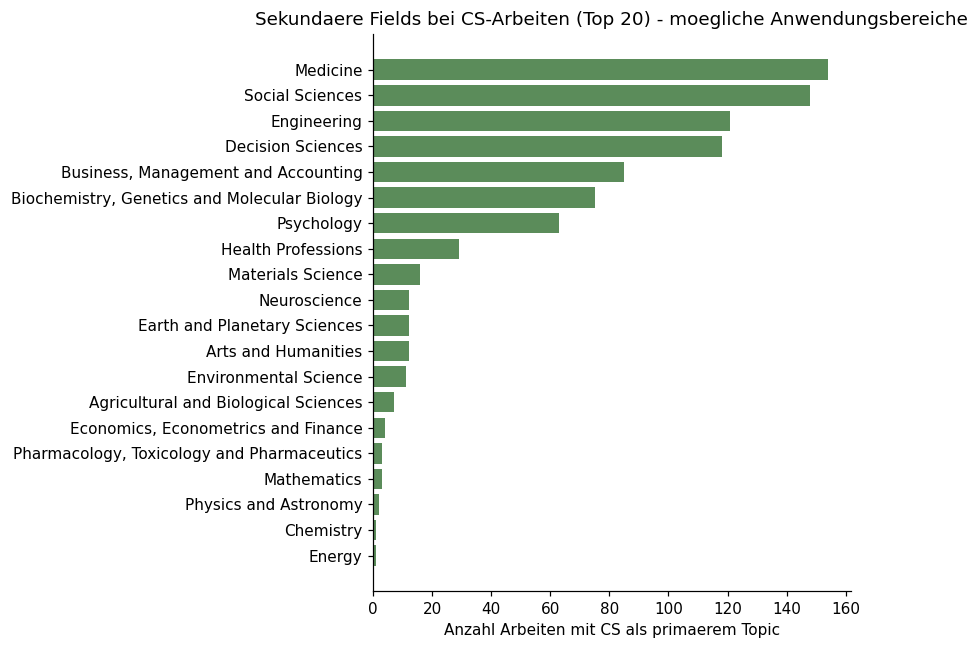

,anwendungsfield,anzahl_arbeiten
0,Medicine,154
1,Social Sciences,148
2,Engineering,121
3,Decision Sciences,118
4,"Business, Management and Accounting",85
5,"Biochemistry, Genetics and Molecular Biology",75
6,Psychology,63
7,Health Professions,29
8,Materials Science,16
9,Neuroscience,12


In [82]:
query_cross_field = """
WITH primary_topic AS (
    SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id
    FROM work_topic wt
    ORDER BY wt.work_id, wt.score DESC
),
cs_works AS (
    SELECT pt.work_id
    FROM primary_topic pt
    JOIN topic t ON pt.topic_id = t.id
    JOIN subfield sf ON t.subfield_id = sf.id
    JOIN field f ON sf.field_id = f.id
    WHERE f.display_name = 'Computer Science'
)
SELECT f.display_name AS anwendungsfield, COUNT(DISTINCT wt.work_id) AS anzahl_arbeiten
FROM work_topic wt
JOIN cs_works cw ON wt.work_id = cw.work_id
JOIN topic t ON wt.topic_id = t.id
JOIN subfield sf ON t.subfield_id = sf.id
JOIN field f ON sf.field_id = f.id
WHERE f.display_name != 'Computer Science'
GROUP BY f.display_name
ORDER BY anzahl_arbeiten DESC
LIMIT 20;
"""

df_cross_field = pd.read_sql(query_cross_field, conn)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(df_cross_field["anwendungsfield"], df_cross_field["anzahl_arbeiten"], color="#5b8c5a")
ax.invert_yaxis()
ax.set_xlabel("Anzahl Arbeiten mit CS als primaerem Topic")
ax.set_title("Sekundaere Fields bei CS-Arbeiten (Top 20) - moegliche Anwendungsbereiche")
plt.tight_layout()
plt.show()

df_cross_field

## 7. Identifikation möglicher Forschungslücken

Ein einfacher, aber wirkungsvoller Ansatz: Für jedes CS-Topic wird die **Gesamtanzahl** der Arbeiten
der **Recency** (Anteil der Arbeiten aus den letzten 2 Jahren) gegenübergestellt.

- **Wenige Arbeiten insgesamt, aber hoher Recency-Anteil** → aufkommendes, noch wenig erschlossenes Thema
  → potenzielle Forschungslücke / lohnenswerter Fokus für den Survey
- **Viele Arbeiten insgesamt, niedriger Recency-Anteil** → etabliertes, eher gesättigtes Thema

Die Streudiagramm-Darstellung (Quadrantenanalyse) macht das visuell greifbar.

In [83]:
query_gap = """
WITH primary_topic AS (
    SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id
    FROM work_topic wt
    ORDER BY wt.work_id, wt.score DESC
),
cs_topic_work AS (
    SELECT pt.work_id, t.display_name AS topic, w.publication_year
    FROM primary_topic pt
    JOIN topic t ON pt.topic_id = t.id
    JOIN subfield sf ON t.subfield_id = sf.id
    JOIN field f ON sf.field_id = f.id
    JOIN work w ON pt.work_id = w.id
    WHERE f.display_name = 'Computer Science'
),
max_year AS (
    SELECT MAX(publication_year) AS letztes_jahr FROM work
)
SELECT topic,
       COUNT(*) AS anzahl_gesamt,
       SUM(CASE WHEN publication_year >= (SELECT letztes_jahr FROM max_year) - 1
                THEN 1 ELSE 0 END) AS anzahl_letzte_2_jahre,
       ROUND(100.0 * SUM(CASE WHEN publication_year >= (SELECT letztes_jahr FROM max_year) - 1
                               THEN 1 ELSE 0 END) / COUNT(*), 1) AS anteil_letzte_2_jahre_prozent
FROM cs_topic_work
GROUP BY topic
HAVING COUNT(*) >= 3
ORDER BY anteil_letzte_2_jahre_prozent DESC, anzahl_gesamt ASC;
"""

df_gap = pd.read_sql(query_gap, conn)
df_gap.head(20)

,topic,anzahl_gesamt,anzahl_letzte_2_jahre,anteil_letzte_2_jahre_prozent
0,Cloud Data Security Solutions,3,3,100.0
1,Artificial Intelligence Applications,3,3,100.0
2,Text and Document Classification Technologies,4,4,100.0
3,Educational Technology and Assessment,4,4,100.0
4,Generative Adversarial Networks and Image Synthesis,4,4,100.0
5,Mobile Agent-Based Network Management,5,5,100.0
6,ICT in Developing Communities,5,5,100.0
7,Persona Design and Applications,5,5,100.0
8,Context-Aware Activity Recognition Systems,6,6,100.0
9,Web Application Security Vulnerabilities,9,9,100.0


Da `anzahl_gesamt` bei 3999 Arbeiten stark rechtsschief verteilt ist (wenige sehr große Topics,
viele kleine) und eine reine Punktwolke mit vielen Beschriftungen schnell unleserlich wird, folgt die
Quadrantenansicht mit **logarithmischer X-Achse** und farblich hinterlegten Quadranten. Die Top-10-Kandidaten
(nach einem einfachen *Gap-Score* = Recency-Anteil / Anzahl Arbeiten) liegen im Diagramm oft sehr dicht
beieinander – ausgeschriebene Text-Labels würden sich dort gegenseitig überlappen und unleserlich werden.
Deshalb werden die Punkte stattdessen nur **nummeriert**; die Zuordnung Nummer → Topic-Name steht in der
Tabelle direkt darunter. Direkt danach folgt zusätzlich ein **Ranked-Bar-Chart** ausschließlich der
Gap-Kandidaten – das ist die am besten lesbare Form und eignet sich gut als Prioritätenliste für die
vertiefte Literaturarbeit.

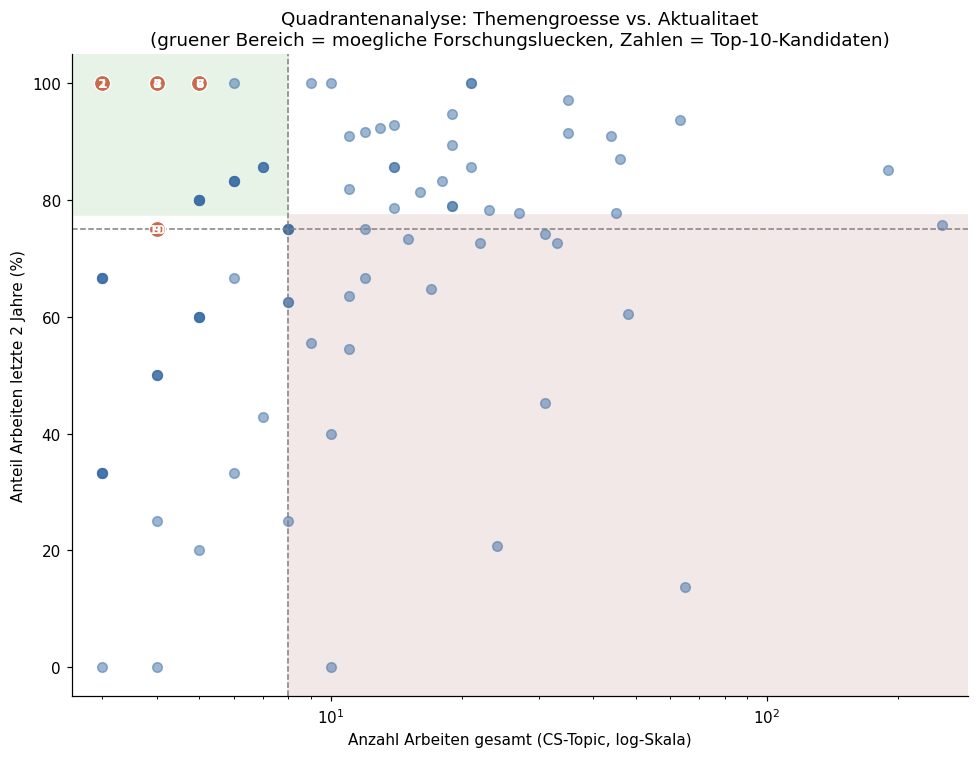

,topic,anzahl_gesamt,anteil_letzte_2_jahre_prozent,gap_score
1,Cloud Data Security Solutions,3,100.0,33.333333
2,Artificial Intelligence Applications,3,100.0,33.333333
3,Text and Document Classification Technologies,4,100.0,25.000000
4,Educational Technology and Assessment,4,100.0,25.000000
5,Generative Adversarial Networks and Image Synthesis,4,100.0,25.000000
6,Mobile Agent-Based Network Management,5,100.0,20.000000
7,ICT in Developing Communities,5,100.0,20.000000
8,Persona Design and Applications,5,100.0,20.000000
9,Energy Efficient Wireless Sensor Networks,4,75.0,18.750000
10,Network Packet Processing and Optimization,4,75.0,18.750000


In [84]:
fig, ax = plt.subplots(figsize=(9, 7))

median_x = df_gap["anzahl_gesamt"].median()
median_y = df_gap["anteil_letzte_2_jahre_prozent"].median()
xmin = df_gap["anzahl_gesamt"].min() * 0.85
xmax = df_gap["anzahl_gesamt"].max() * 1.15

# Quadranten farblich hinterlegen: oben-links = potenzielle Forschungsluecken
ax.axvspan(xmin, median_x, ymin=median_y / 100, ymax=1, color="#e8f3e8", zorder=0)
ax.axvspan(median_x, xmax, ymin=0, ymax=median_y / 100, color="#f3e8e8", zorder=0)

# Alle Topics als kleine, dezente Punkte
ax.scatter(df_gap["anzahl_gesamt"], df_gap["anteil_letzte_2_jahre_prozent"],
           s=40, color="#3b6ea5", alpha=0.5, zorder=2)

ax.axvline(median_x, color="grey", linestyle="--", linewidth=1)
ax.axhline(median_y, color="grey", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xlim(xmin, xmax)

# Gap-Kandidaten: klein, aber ueberdurchschnittlich aktuell
gap_candidates = df_gap[(df_gap["anzahl_gesamt"] <= median_x) &
                         (df_gap["anteil_letzte_2_jahre_prozent"] >= median_y)].copy()
gap_candidates["gap_score"] = (gap_candidates["anteil_letzte_2_jahre_prozent"]
                                / gap_candidates["anzahl_gesamt"])

# Top-10 hervorheben und NUMMERIEREN statt mit Text zu beschriften
# (Text-Labels wuerden bei eng beieinander liegenden Punkten ueberlappen)
top_labels = gap_candidates.sort_values("gap_score", ascending=False).head(10).reset_index(drop=True)
top_labels.index = top_labels.index + 1  # 1-basierte Nummerierung fuer die Anzeige

ax.scatter(top_labels["anzahl_gesamt"], top_labels["anteil_letzte_2_jahre_prozent"],
           s=110, color="#c96a4d", edgecolor="white", linewidth=0.8, zorder=3)

for nr, row in top_labels.iterrows():
    ax.annotate(str(nr), (row["anzahl_gesamt"], row["anteil_letzte_2_jahre_prozent"]),
                fontsize=8, fontweight="bold", color="white",
                ha="center", va="center", zorder=4)

ax.set_xlabel("Anzahl Arbeiten gesamt (CS-Topic, log-Skala)")
ax.set_ylabel("Anteil Arbeiten letzte 2 Jahre (%)")
ax.set_title("Quadrantenanalyse: Themengroesse vs. Aktualitaet\n(gruener Bereich = moegliche Forschungsluecken, Zahlen = Top-10-Kandidaten)")
plt.tight_layout()
plt.show()

# Legende: Nummer -> Topic-Name
top_labels[["topic", "anzahl_gesamt", "anteil_letzte_2_jahre_prozent", "gap_score"]]

### 7.1 Alternative Darstellung: Ranked-Bar-Chart der Gap-Kandidaten

Statt einer Punktwolke mit Beschriftungen zeigt dieses Balkendiagramm die Top-15-Gap-Kandidaten
sortiert nach Aktualitätsanteil, mit der jeweiligen Stichprobengröße (`n=`) als Zusatzinfo direkt
am Balken. Das ist die praktischste Form für eine konkrete Prioritätenliste im Survey.

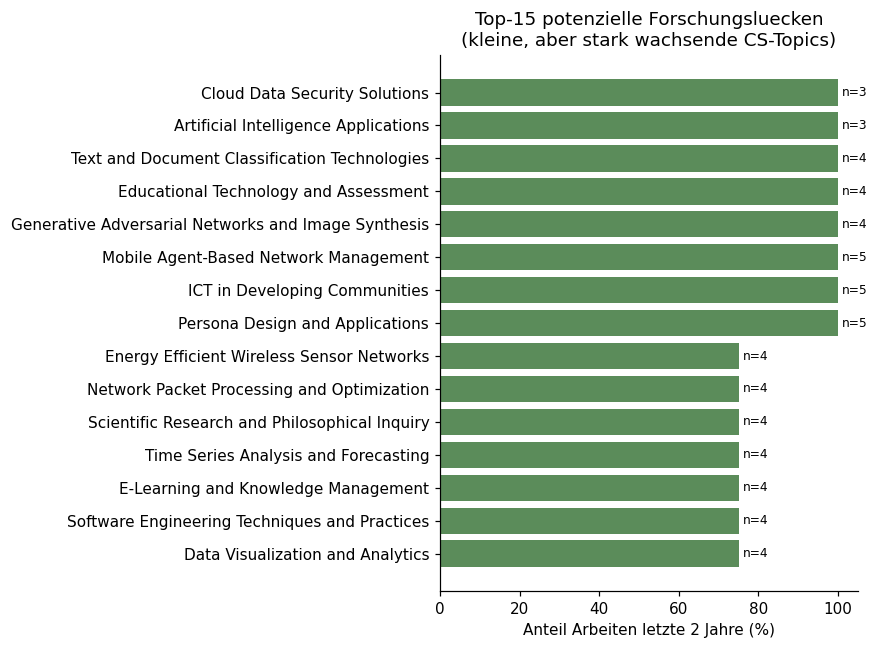

,topic,anzahl_gesamt,anteil_letzte_2_jahre_prozent,gap_score
0,Cloud Data Security Solutions,3,100.0,33.333333
1,Artificial Intelligence Applications,3,100.0,33.333333
2,Text and Document Classification Technologies,4,100.0,25.000000
3,Educational Technology and Assessment,4,100.0,25.000000
4,Generative Adversarial Networks and Image Synthesis,4,100.0,25.000000
5,Mobile Agent-Based Network Management,5,100.0,20.000000
6,ICT in Developing Communities,5,100.0,20.000000
7,Persona Design and Applications,5,100.0,20.000000
53,Energy Efficient Wireless Sensor Networks,4,75.0,18.750000
54,Network Packet Processing and Optimization,4,75.0,18.750000


In [85]:
top_gap_bar = gap_candidates.sort_values("gap_score", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top_gap_bar["topic"], top_gap_bar["anteil_letzte_2_jahre_prozent"], color="#5b8c5a")
ax.invert_yaxis()
for bar, n in zip(bars, top_gap_bar["anzahl_gesamt"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"n={n}",
            va="center", fontsize=8)
ax.set_xlim(0, 105)
ax.set_xlabel("Anteil Arbeiten letzte 2 Jahre (%)")
ax.set_title("Top-15 potenzielle Forschungsluecken\n(kleine, aber stark wachsende CS-Topics)")
plt.tight_layout()
plt.show()

top_gap_bar[["topic", "anzahl_gesamt", "anteil_letzte_2_jahre_prozent", "gap_score"]]

## 8. Ergänzende Textanalyse auf Abstract-Ebene

Die bisherigen Auswertungen basieren auf den von OpenAlex vergebenen Topics/Keywords. Ergänzend
lohnt sich ein Blick in die **Abstracts selbst** (`work.abstract_inverted_index`), da diese die
inhaltliche Tiefe liefern, die eine grobe Topic-Klassifikation nicht abbildet.

OpenAlex speichert Abstracts nicht als Fließtext, sondern als *invertierten Index*
(`{"wort": [Position1, Position2, ...], ...}`) – aus Lizenz-/Platzgründen. Der folgende Code
rekonstruiert daraus den lesbaren Text und bereitet ihn für die Analyse auf (Kleinschreibung,
Tokenisierung, Stoppwort-Filterung).

In [86]:
import re
import json
from collections import Counter

def reconstruct_abstract(inv_index):
    """Rekonstruiert den Abstract-Volltext aus dem OpenAlex invertierten Index."""
    if inv_index is None:
        return ""
    if isinstance(inv_index, str):
        inv_index = json.loads(inv_index)
    positions = []
    for word, idxs in inv_index.items():
        for idx in idxs:
            positions.append((idx, word))
    positions.sort()
    return " ".join(w for _, w in positions)

STOPWORDS = set("""a about above after again against all am an and any are aren't as at be because
been before being below between both but by can't cannot could couldn't did didn't do does doesn't
doing don't down during each few for from further had hadn't has hasn't have haven't having he he'd
he'll he's her here here's hers herself him himself his how how's i i'd i'll i'm i've if in into is
isn't it it's its itself let's me more most mustn't my myself no nor not of off on once only or other
ought our ours ourselves out over own same shan't she she'd she'll she's should shouldn't so some such
than that that's the their theirs them themselves then there there's these they they'd they'll they're
they've this those through to too under until up very was wasn't we we'd we'll we're we've were
weren't what what's when when's where where's which while who who's whom why why's with won't would
wouldn't you you'd you'll you're you've your yours yourself yourselves using use used based approach
paper propose proposed present study results also however can may one two based new novel method
methods data show shown result article work results paper's et al""".split())

TOKEN_RE = re.compile(r"[a-zA-Z][a-zA-Z\-]{2,}")

def clean_tokens(text):
    tokens = TOKEN_RE.findall(text.lower())
    return [t for t in tokens if t not in STOPWORDS and len(t) > 2]

query_abstracts = """
SELECT id, publication_year, abstract_inverted_index
FROM work
WHERE abstract_inverted_index IS NOT NULL;
"""

df_abstracts = pd.read_sql(query_abstracts, conn)
df_abstracts["abstract_text"] = df_abstracts["abstract_inverted_index"].apply(reconstruct_abstract)

print(f"Abstracts verfuegbar fuer {len(df_abstracts)} von 3999 Arbeiten")
df_abstracts[["id", "publication_year", "abstract_text"]].head(3)

Abstracts verfuegbar fuer 3860 von 3999 Arbeiten


,id,publication_year,abstract_text
0,W2997853471,2016.0,
1,W253400794,2004.0,
2,W4408957503,2025.0,Our validated large language model-based tool effectively automates the transformation of clinical data into the OMO...


### 8.1 Häufigste inhaltstragende Begriffe

Top-30-Wörter über alle verfügbaren Abstracts hinweg (nach Stoppwort-Filterung). Das ist ein
schneller Reality-Check, ob die dominanten Begriffe zur Erwartung ("vector", "search", "index",
"embedding", "database", ...) passen und liefert zusätzliches Vokabular für Suchstrings.

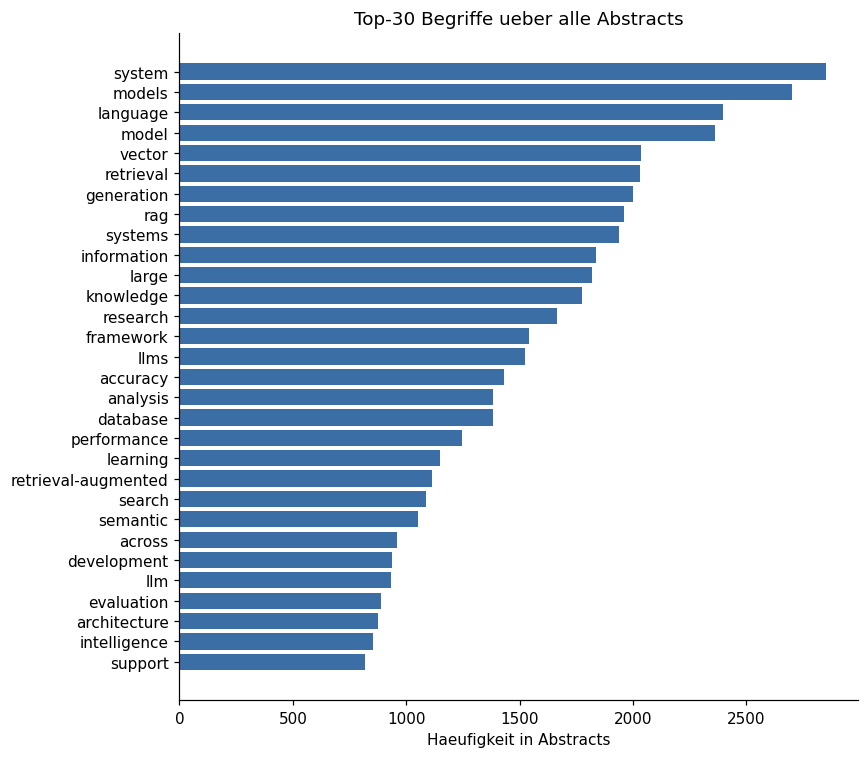

,begriff,anzahl
0,system,2850
1,models,2701
2,language,2395
3,model,2361
4,vector,2035
5,retrieval,2029
6,generation,2002
7,rag,1962
8,systems,1940
9,information,1837


In [87]:
overall_counts = Counter()
for text in df_abstracts["abstract_text"]:
    overall_counts.update(clean_tokens(text))

top_terms = pd.DataFrame(overall_counts.most_common(30), columns=["begriff", "anzahl"])

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_terms["begriff"], top_terms["anzahl"], color="#3b6ea5")
ax.invert_yaxis()
ax.set_xlabel("Haeufigkeit in Abstracts")
ax.set_title("Top-30 Begriffe ueber alle Abstracts")
plt.tight_layout()
plt.show()

top_terms

### 8.2 Trend ausgewählter Fachbegriffe über die Jahre

Statt einzelner Wörter werden hier gezielt technische Begriffe/Phrasen gesucht, die für
Vektordatenbanken charakteristisch sind. Das zeigt z. B., ob bestimmte Indexierungsverfahren
(HNSW, Quantisierung) oder Anwendungen (Retrieval-Augmented Generation) in den letzten Jahren
an Erwähnung zugenommen haben – eine feinere Auflösung als die Topic-Ebene.

**Hinweis:** Die Begriffsliste ist ein Vorschlag und sollte an die tatsächlichen Schwerpunkte
deines Surveys angepasst werden.

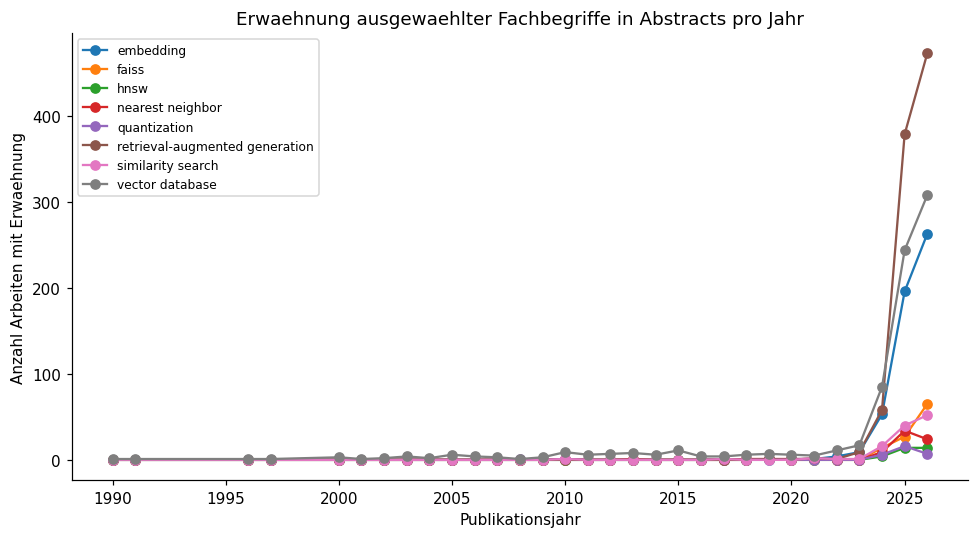

begriff,embedding,faiss,hnsw,nearest neighbor,quantization,retrieval-augmented generation,similarity search,vector database
publication_year,,,,,,,,
1990.0,0,0,0,0,0,0,0,1
1991.0,0,0,0,0,0,0,0,1
1996.0,0,0,0,0,0,0,0,1
1997.0,0,0,0,0,0,0,0,1
2000.0,0,0,0,0,0,0,0,3
2001.0,0,0,0,0,0,0,0,1
2002.0,0,0,0,0,0,0,0,2
2003.0,0,0,0,0,0,0,0,4
2004.0,0,0,0,0,0,0,0,2


In [88]:
fachbegriffe = [
    "hnsw", "faiss", "quantization", "nearest neighbor", "similarity search",
    "embedding", "retrieval-augmented generation", "vector database",
]

rows = []
for _, row in df_abstracts.iterrows():
    text_lower = row["abstract_text"].lower()
    for begriff in fachbegriffe:
        if begriff in text_lower:
            rows.append({"publication_year": row["publication_year"], "begriff": begriff})

df_terms = pd.DataFrame(rows)
term_year = (df_terms.groupby(["publication_year", "begriff"]).size()
             .unstack(fill_value=0).sort_index())

fig, ax = plt.subplots(figsize=(9, 5))
for begriff in term_year.columns:
    ax.plot(term_year.index, term_year[begriff], marker="o", label=begriff)
ax.set_xlabel("Publikationsjahr")
ax.set_ylabel("Anzahl Arbeiten mit Erwaehnung")
ax.set_title("Erwaehnung ausgewaehlter Fachbegriffe in Abstracts pro Jahr")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

term_year

### 8.3 Charakteristische Begriffe der Top-Gap-Themen

Für die zehn Gap-Kandidaten aus Abschnitt 7 (Variable `top_labels`) werden hier die Abstracts der
jeweils zugehörigen Arbeiten geladen und die häufigsten Begriffe berechnet. Über einen einfachen
**Lift-Wert** (relative Häufigkeit im Topic geteilt durch relative Häufigkeit im Gesamtkorpus aus 8.1)
werden Begriffe hervorgehoben, die für dieses Topic *überdurchschnittlich* charakteristisch sind –
das liefert konkrete Suchbegriffe für die vertiefte Literaturrecherche in genau diesen Themen.

In [89]:
total_overall = sum(overall_counts.values())

def charakteristische_begriffe(topic_name, top_n=8, min_count=3):
    query = """
    WITH primary_topic AS (
        SELECT DISTINCT ON (wt.work_id) wt.work_id, wt.topic_id
        FROM work_topic wt
        ORDER BY wt.work_id, wt.score DESC
    )
    SELECT w.abstract_inverted_index
    FROM primary_topic pt
    JOIN topic t ON pt.topic_id = t.id
    JOIN work w ON pt.work_id = w.id
    WHERE t.display_name = %(topic_name)s
      AND w.abstract_inverted_index IS NOT NULL;
    """
    df_topic = pd.read_sql(query, conn, params={"topic_name": topic_name})

    counter = Counter()
    for inv in df_topic["abstract_inverted_index"]:
        counter.update(clean_tokens(reconstruct_abstract(inv)))
    total_topic = sum(counter.values())
    if total_topic == 0:
        return pd.DataFrame(columns=["topic", "begriff", "anzahl", "lift"])

    rows = []
    for word, cnt in counter.items():
        if cnt < min_count:
            continue
        freq_topic = cnt / total_topic
        freq_overall = overall_counts.get(word, 1) / total_overall
        rows.append((topic_name, word, cnt, round(freq_topic / freq_overall, 2)))

    return (pd.DataFrame(rows, columns=["topic", "begriff", "anzahl", "lift"])
            .sort_values("lift", ascending=False)
            .head(top_n))

alle_charakteristika = pd.concat(
    [charakteristische_begriffe(topic) for topic in top_labels["topic"]],
    ignore_index=True
)
alle_charakteristika

,topic,begriff,anzahl,lift
0,Cloud Data Security Solutions,multi-cloud,5,234.66
1,Cloud Data Security Solutions,others,3,86.65
2,Cloud Data Security Solutions,controls,3,76.80
3,Cloud Data Security Solutions,attack,4,54.95
4,Cloud Data Security Solutions,enterprises,3,51.99
...,...,...,...,...
75,Network Packet Processing and Optimization,matching,3,12.58
76,Network Packet Processing and Optimization,security,5,10.73
77,Network Packet Processing and Optimization,embeddings,4,9.61
78,Network Packet Processing and Optimization,query,6,9.24


## 9. Zusammenfassung und nächste Schritte

Aus den obigen Auswertungen lassen sich für den Survey u. a. folgende Bausteine ableiten:

- **Kapitel „Grundlagen/Taxonomie"**: gestützt auf die Domain/Field/Subfield/Topic-Verteilung (Abschnitt 2–3)
- **Kapitel „Zeitliche Entwicklung"**: gestützt auf Publikationstrend und Topic-Jahr-Heatmap (Abschnitt 1.1, 3.2)
- **Kapitel „Kernliteratur"**: Ausgangspunkt sind die meistzitierten Arbeiten (Abschnitt 4)
- **Kapitel „Anwendungsbereiche"**: gestützt auf die Cross-Domain-Analyse (Abschnitt 6)
- **Kapitel „Forschungslücken"**: gestützt auf die Quadrantenanalyse und die charakteristischen
  Begriffe der Gap-Themen (Abschnitt 7–8) – diese Topics sollten gezielt vertieft gelesen werden,
  da sie klein, aber im Wachstum begriffen sind

Als nächster Schritt empfiehlt es sich, für die identifizierten Gap-Kandidaten gezielt die
vollständigen Abstracts (und ggf. Volltexte) zu lesen und die hier gefundenen charakteristischen
Begriffe als Ausgangspunkt für eine gezielte Literatursuche (z. B. in Google Scholar, ACM DL,
IEEE Xplore) zu nutzen.

In [90]:
conn.close()